# **Лабораторная работа 1. Линейная регрессия и факторный анализ**

# **Краткое описание целей и задач работы**
### Цель работы
Изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.

### Задачи
1.   Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).
2.   Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.
3.   Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).
4.   Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).
5.   Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).
6.   Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA). Перед проведением PCA провести стандартизацию данных.
7.   Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

# **Описание датасета**

Датасет состоит из 5 файлов:
*   Red.csv - красные вина
*   White.csv - белые вина
*   Rose.csv - розовые вина
*   Sparkling.csv - игристые вина
*   Varieties.csv - сорта винограда

В работе использовано 4 файла: Red, White, Rose, Sparkling.




In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
RANDOM_STATE = 42

red = pd.read_csv('Red.csv')
white = pd.read_csv('White.csv')
rose = pd.read_csv('Rose.csv')
sparkling = pd.read_csv('Sparkling.csv')

Датасет содержит 13 834 строк и 8 столбцов.

Столбцы:
*   Name (текст) - название вина
*   Country (категория) - страна-производитель
*   Region (категория) - регион производства
*   Winery	(категория)	 - винодельня
*   Rating (float64) - средний рейтинг вина
*   NumberOfRatings	(int64) -	количество оценок
*   Price	(float64) - цена вина в долларах
*   Year (float64) - год урожая

Целевая переменная - Rating - средний рейтинг вина.

In [92]:
dt = pd.concat([red, white, rose, sparkling], ignore_index=True)
dt['Year'] = pd.to_numeric(dt['Year'], errors='coerce')

print("Размер датасета:", dt.shape)
print(dt.head())

print("\nИнформация о датасете")

dt.info()
print("\nОписательная статистика числовых признаков:\n", dt.describe())
print("\nПропуски по столбцам:")
print(dt.isnull().sum().sort_values(ascending=False))

print("\nУдаление уникальных признаков")
drop_columns = ['Name', 'Winery', 'Region']
for column in drop_columns:
    if column in dt.columns:
        dt = dt.drop(columns=column)

Размер датасета: (13834, 8)
                                 Name  Country     Region  \
0                        Pomerol 2011   France    Pomerol   
1                          Lirac 2017   France      Lirac   
2  Erta e China Rosso di Toscana 2015    Italy    Toscana   
3                      Bardolino 2019    Italy  Bardolino   
4      Ried Scheibner Pinot Noir 2016  Austria  Carnuntum   

                  Winery  Rating  NumberOfRatings  Price    Year  
0  Château La Providence     4.2              100  95.00  2011.0  
1     Château Mont-Redon     4.3              100  15.50  2017.0  
2             Renzo Masi     3.9              100   7.45  2015.0  
3             Cavalchina     3.5              100   8.72  2019.0  
4            Markowitsch     3.9              100  29.15  2016.0  

Информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13834 entries, 0 to 13833
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           ----

# Графики распределения признаков

### Визуализация числовых признаков


Визуализация числовых признаков


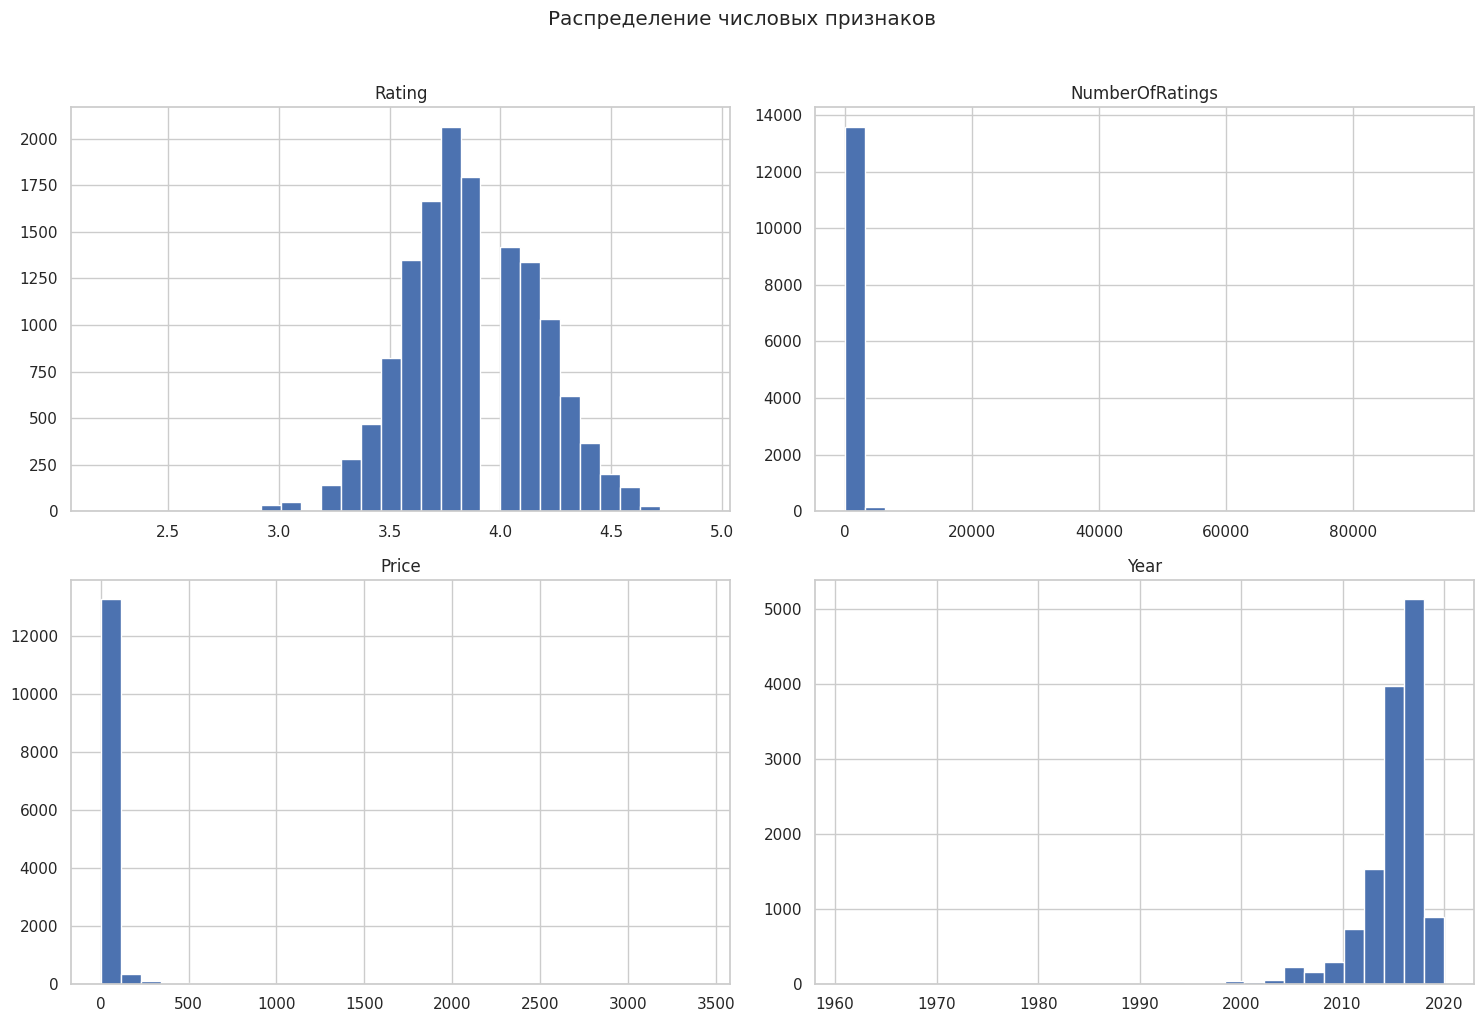

In [93]:
print("\nВизуализация числовых признаков")
numeric_cols = dt.select_dtypes(include=[np.number]).columns
dt[numeric_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle('Распределение числовых признаков', y=1.02)
plt.tight_layout()
plt.show()

### Визуализация категориальных признаков

Визуализация категориальных признаков


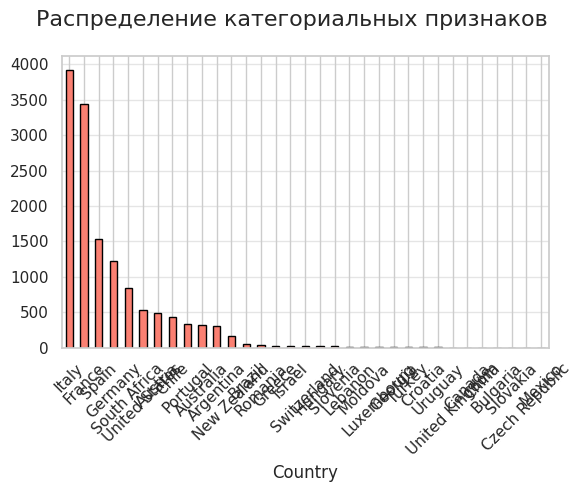

In [94]:
print("Визуализация категориальных признаков")
categorical_features = dt.select_dtypes(include=['object']).columns.tolist()

num_categorical = len(categorical_features)

if num_categorical > 0:
    fig, axes = plt.subplots(1, num_categorical, figsize=(6 * num_categorical, 5))
    if num_categorical == 1:
        axes = [axes]

    fig.suptitle('Распределение категориальных признаков', fontsize=16)

    for i, col in enumerate(categorical_features):
        top_values = dt[col].value_counts()
        top_values.plot(kind='bar', ax=axes[i],
                        color='salmon', edgecolor='black')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(axis='y', alpha=0.5)

    plt.tight_layout()
    plt.show()

### Визуализация целевой переменной

Визуализация целевой переменной


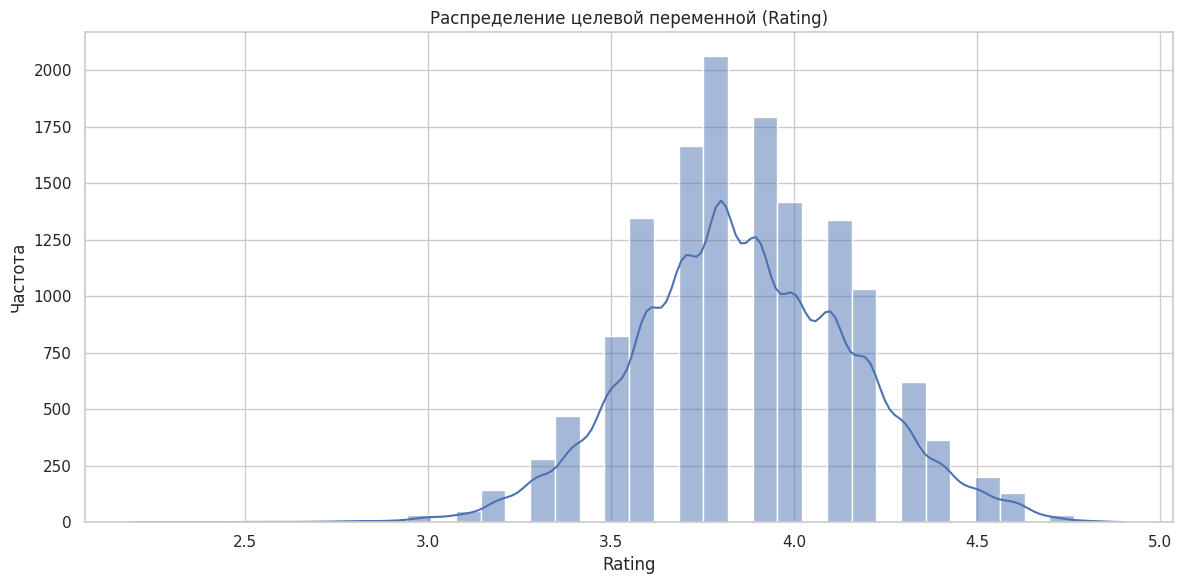

In [95]:
print("Визуализация целевой переменной")
sns.histplot(dt['Rating'].dropna(), kde=True, bins=40)
plt.title('Распределение целевой переменной (Rating)')
plt.xlabel('Rating')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

target = 'Rating'

# **Подготовка данных**
### Удаление пропусков


In [96]:
dt = dt.dropna(subset=numeric_cols)
print("После удаления лишних столбцов и пропусков осталось:", dt.shape)

После удаления лишних столбцов и пропусков осталось: (13090, 5)


### Объединение редко попадающихся стран

In [97]:
print("\nОбъединение редко попадающихся стран в 'Other'")
category_columns = dt.select_dtypes(include=['object']).columns.tolist()

if 'Country' in dt.columns:
    print("Страны до объединения:", dt['Country'].nunique())
    countries = dt['Country'].value_counts().head(10).index
    dt['Country'] = dt['Country'].where(
        dt['Country'].isin(countries), 'Other'
    )
    print("Страны после объединения:", dt['Country'].nunique())


Объединение редко попадающихся стран в 'Other'
Страны до объединения: 33
Страны после объединения: 11


### Кодирование категориальных переменных

In [98]:
dt = pd.get_dummies(dt, columns=category_columns, drop_first=True)
print("После кодирования:", dt.shape)

После кодирования: (13090, 14)


# **Корреляционная матрица и VIF**
### Корреляционная матрица

Вывод корреляционной матрицы


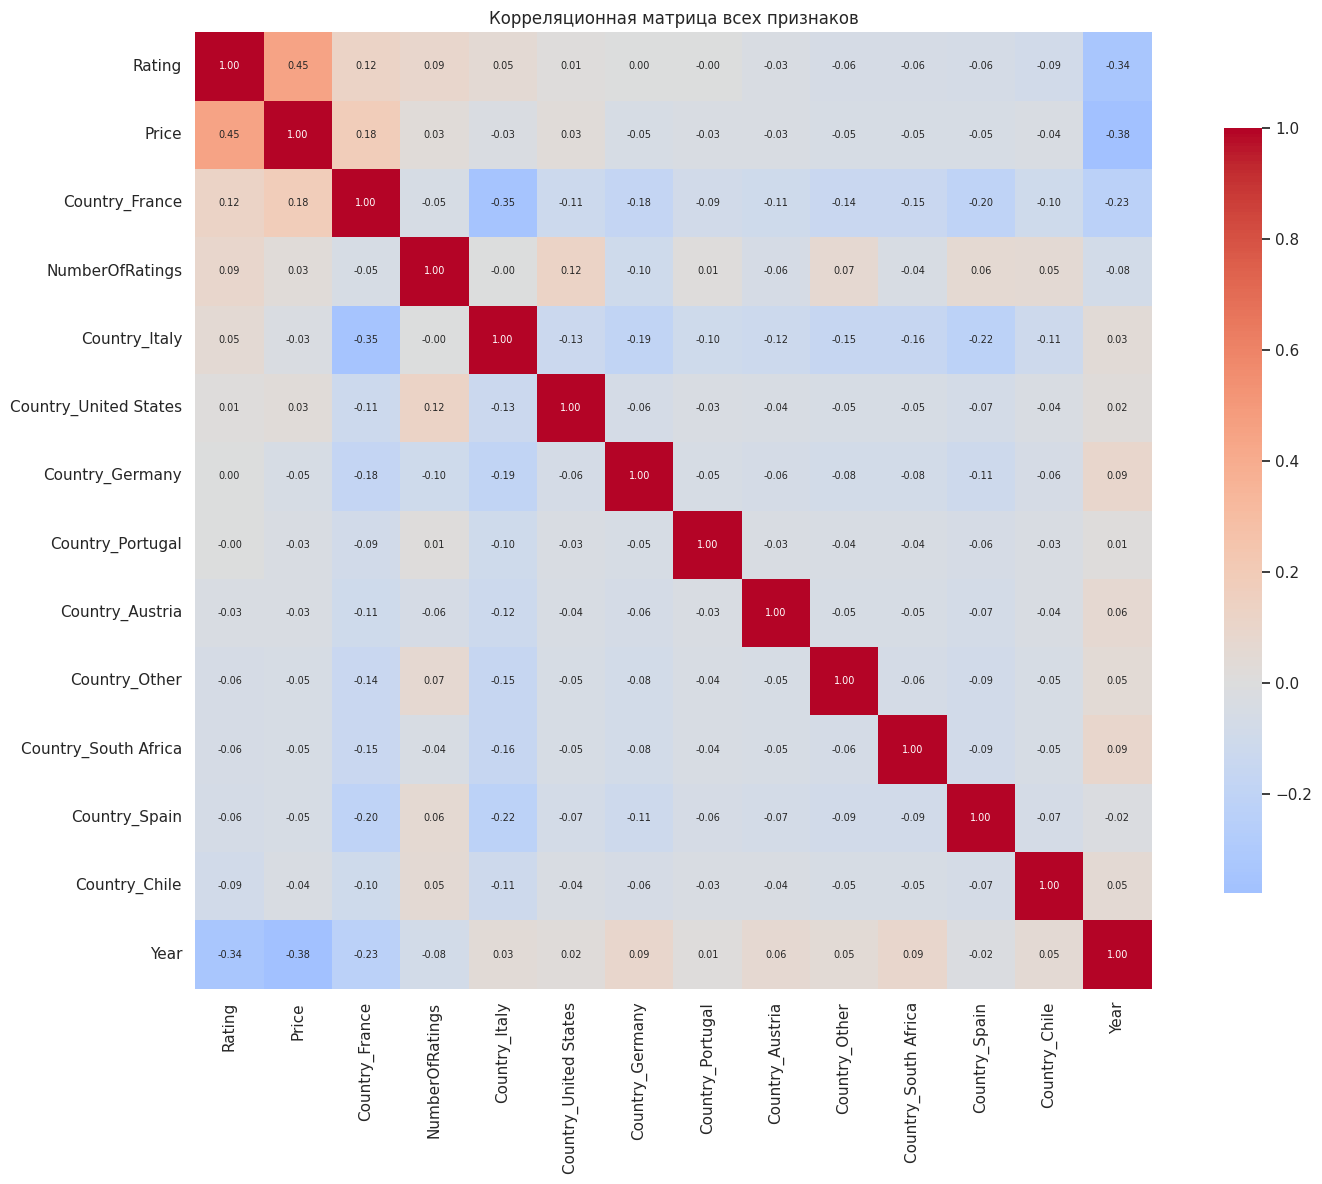

In [99]:
print("Вывод корреляционной матрицы")
matrix = dt.corr()['Rating'].sort_values(ascending=False)
ordered_cols = matrix.index.tolist()

plt.figure(figsize=(16, 12))
sns.heatmap(dt[ordered_cols].corr(), annot=True, cmap='coolwarm',
            center=0, fmt='.2f', square=True,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица всех признаков')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

x = dt.drop(columns=[target])
y = dt[target]

Анализ матрицы корреляций показывает умеренную связь между Rating и Price, коэффициенты корреляции между которыми 0.45. Year имеет заметную связь с Rating, коэффициенты корреляции между ними -0.34. А Country почти не влияет на Rating - их корреляции не превышают ±0.12.

Также обнаружена умеренная корреляция между признаками Country_France и Country_Italy (r = −0.35), что указывает на мультиколлинеарность.

### VIF

In [100]:
print("\nVIF:")
x_vif = x.copy()
x_vif = x_vif.replace([np.inf, -np.inf], np.nan).fillna(x_vif.median())

vif_data = pd.DataFrame()
vif_data["feature"] = x_vif.columns
vif_data["VIF"] = [variance_inflation_factor(x_vif.values, i)
                   for i in range(x_vif.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))


VIF:
                  feature       VIF
7           Country_Italy  9.118859
5          Country_France  8.460329
11          Country_Spain  5.103667
6         Country_Germany  4.343656
10   Country_South Africa  3.435038
8           Country_Other  3.200556
12  Country_United States  2.583460
3         Country_Austria  2.437759
4           Country_Chile  2.297098
9        Country_Portugal  1.996475
2                    Year  1.228018
1                   Price  1.187725
0         NumberOfRatings  1.049432


Порог VIF = 10 не превышен. Максимальное значение - 9.118859 у Country_Italy. Значит, критической мультиколлинеарности нет, и модель линейной регрессии может работать без серьёзных искажений. Однако Country_Italy и Country_France - на грани. Их VIF близки к 10, что говорит о сильной взаимосвязи между этими признаками.

# **Ход работы**
## Регрессионные модели и кросс-валидация
### Подготовка данных
Датасет был разделён на тренировочную (80%) и тестовую (20%) выборки.

In [101]:
print("Деление на тестовую и тренировочную выборки\n")
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Тренировочная:", x_train.shape, "Тестовая:", x_test.shape, "\n")

Деление на тестовую и тренировочную выборки

Тренировочная: (10472, 13) Тестовая: (2618, 13) 



### Регрессионные модели
Для подсчёта метрик качества (RMSE, R2, MAPE) была написана функция Evaluate:

In [102]:
def Evaluate(model, x_tr, y_tr, x_te, y_te, name):
    model.fit(x_tr, y_tr)
    y_pred = model.predict(x_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    mape = mean_absolute_percentage_error(y_te, y_pred) * 100
    return {'model': name, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

Для вывода результатов метрик была написана функция Print_Results:

In [103]:
def Print_Results(results):
    for res in results:
        if res['model'] == "Лассо":
            print(f"{res['model']}\t\t | RMSE={res['RMSE']}\t | R²={res['R2']}\t | MAPE={res['MAPE']}%")
        else:
            print(f"{res['model']}\t | RMSE={res['RMSE']}\t | R²={res['R2']}\t | MAPE={res['MAPE']}%")

Наконец, вот так выглядела работа с регрессионными моделями:

In [104]:
print("Регрессионные модели")
results = []
results.append(Evaluate(LinearRegression(),
                        x_train, y_train, x_test, y_test, "Линейная"))
results.append(Evaluate(Lasso(alpha=0.001, max_iter=10000),
                        x_train, y_train, x_test, y_test, "Лассо"))
results.append(Evaluate(Ridge(alpha=1.0),
                        x_train, y_train, x_test, y_test, "Гребневая"))

Print_Results(results)

Регрессионные модели
Линейная	 | RMSE=0.2757886662268048	 | R²=0.1632145922095979	 | MAPE=5.28156730215262%
Лассо		 | RMSE=0.27674596171790367	 | R²=0.1573953453153939	 | MAPE=5.3011735616871505%
Гребневая	 | RMSE=0.27580275837568075	 | R²=0.16312907451244596	 | MAPE=5.281888610045836%


Все три модели показали почти одинаковые результаты (R2 ≈ 0.16, RMSE ≈ 0.276, MAPE ≈ 5.28%).

### Кросс-валидация

In [105]:
print("\nКросс-валидация")
cv = cross_val_score(LinearRegression(), x, y, cv=5, scoring='r2')
print(f"CV R² (Линейная): {cv.mean()} ± {cv.std()}")
cv = cross_val_score(Lasso(), x, y, cv=5, scoring='r2')
print(f"CV R² (Лассо): {cv.mean()} ± {cv.std()}")
cv = cross_val_score(Ridge(), x, y, cv=5, scoring='r2')
print(f"CV R² (Гребневая): {cv.mean()} ± {cv.std()}")


Кросс-валидация
CV R² (Линейная): 0.2302618425192172 ± 0.03327802017361817
CV R² (Лассо): 0.18913784420779717 ± 0.032123143937256994
CV R² (Гребневая): 0.2302779001237361 ± 0.033262247206087274


Модели устойчивы, результат воспроизводим. Линейная и Гребневая эквивалентны - что подтверждает умеренную мультиколлинеарность в данных.

## PCA

PCA


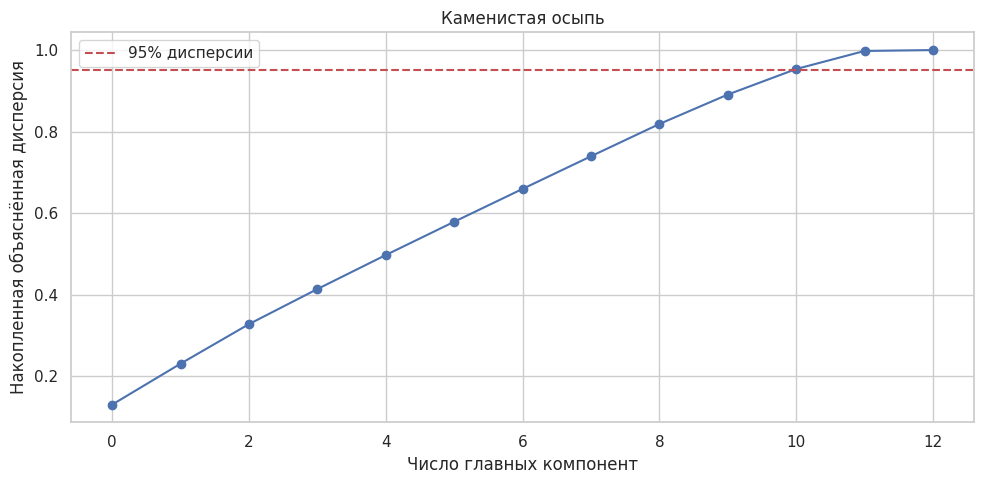

Оптимальное число компонент для 95% дисперсии: 11
Размер после PCA: (10472, 11)


In [106]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("PCA")
pca_full = PCA()
pca_full.fit(x_train_scaled)

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.xlabel('Число главных компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.title('Каменистая осыпь')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

variance = np.cumsum(pca_full.explained_variance_ratio_)
num_components = np.argmax(variance >= 0.95) + 1
print(f"Оптимальное число компонент для 95% дисперсии: {num_components}")

pca = PCA(n_components=num_components)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)
print("Размер после PCA:", x_train_pca.shape)

Так как страны почти не коррелируют между собой, то кривая на графике растёт равномерно и резкого "локтя" на нём нет, то есть, данные слабо сжимаемы. Но размерность всё же снижена с 13 до 11.

## Регрессионные модели после PCA

In [107]:
print("Регрессионные модели после PCA")
results.append(Evaluate(LinearRegression(),
                        x_train_pca, y_train, x_test_pca, y_test,
                        "Линейная + PCA"))
results.append(Evaluate(Lasso(alpha=0.001, max_iter=10000),
                        x_train_pca, y_train, x_test_pca, y_test,
                        "Лассо + PCA"))
results.append(Evaluate(Ridge(alpha=1.0),
                        x_train_pca, y_train, x_test_pca, y_test,
                        "Гребневая + PCA"))

Print_Results(results)

results_dt = pd.DataFrame(results)

Регрессионные модели после PCA
Линейная	 | RMSE=0.2757886662268048	 | R²=0.1632145922095979	 | MAPE=5.28156730215262%
Лассо		 | RMSE=0.27674596171790367	 | R²=0.1573953453153939	 | MAPE=5.3011735616871505%
Гребневая	 | RMSE=0.27580275837568075	 | R²=0.16312907451244596	 | MAPE=5.281888610045836%
Линейная + PCA	 | RMSE=0.2699841220246889	 | R²=0.19806768080490134	 | MAPE=5.351161624370181%
Лассо + PCA	 | RMSE=0.26978375167768837	 | R²=0.1992575569336481	 | MAPE=5.3550860686606%
Гребневая + PCA	 | RMSE=0.26998239410219776	 | R²=0.19807794564896763	 | MAPE=5.351179437237487%


### Изменения RMSE

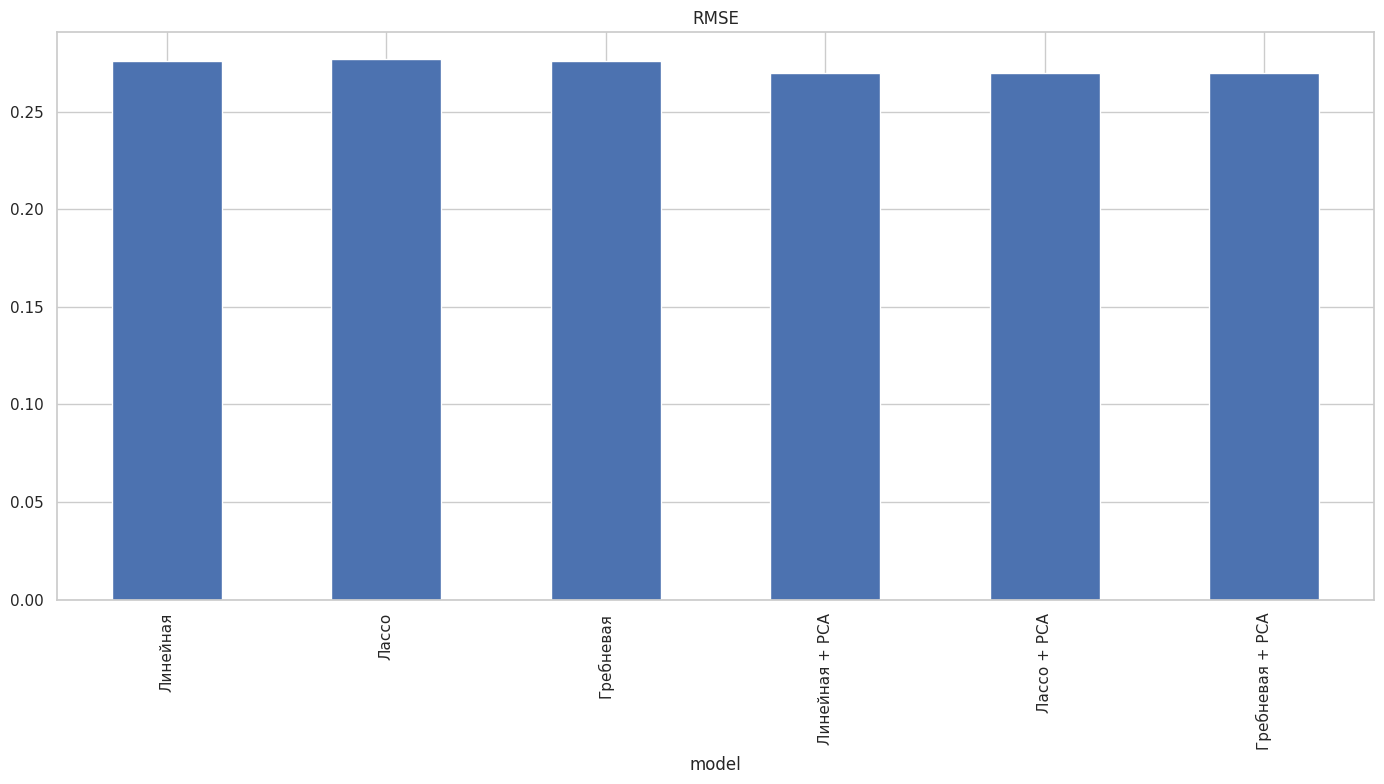

In [108]:
results_dt.set_index('model')[['RMSE']].plot(
    kind='bar', subplots=True, figsize=(14, 8), legend=False
)
plt.tight_layout()
plt.show()

RMSE снизился после PCA у всех трёх моделей. Средняя ошибка предсказания рейтинга снизилась, хоть и на небольшое значение (с 0.28 до 0.27).

### Изменения R2

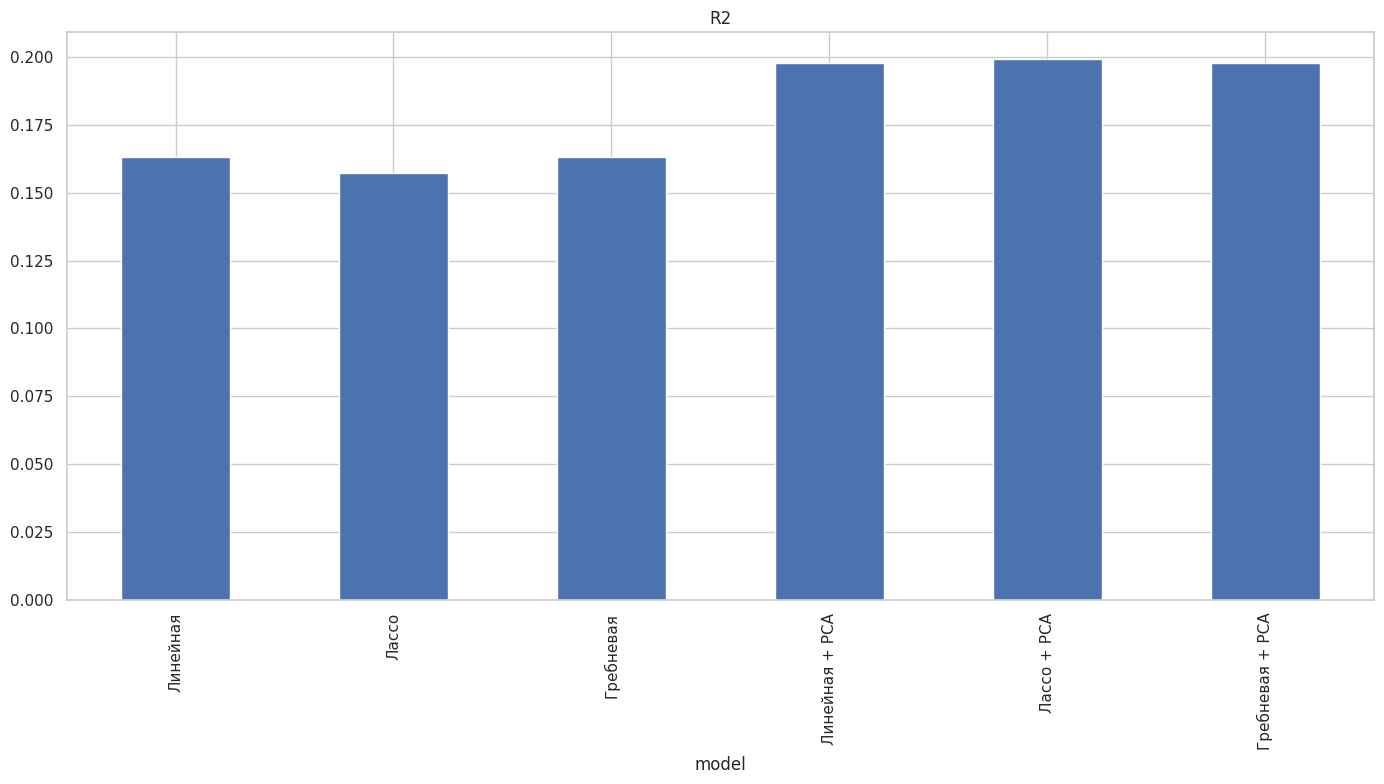

In [109]:
results_dt.set_index('model')[['R2']].plot(
    kind='bar', subplots=True, figsize=(14, 8), legend=False
)
plt.tight_layout()
plt.show()

R2 вырос после PCA у всех трёх моделей. Причём вырос заметно: с 0.17 до 0.20.

### Изменения MAPE

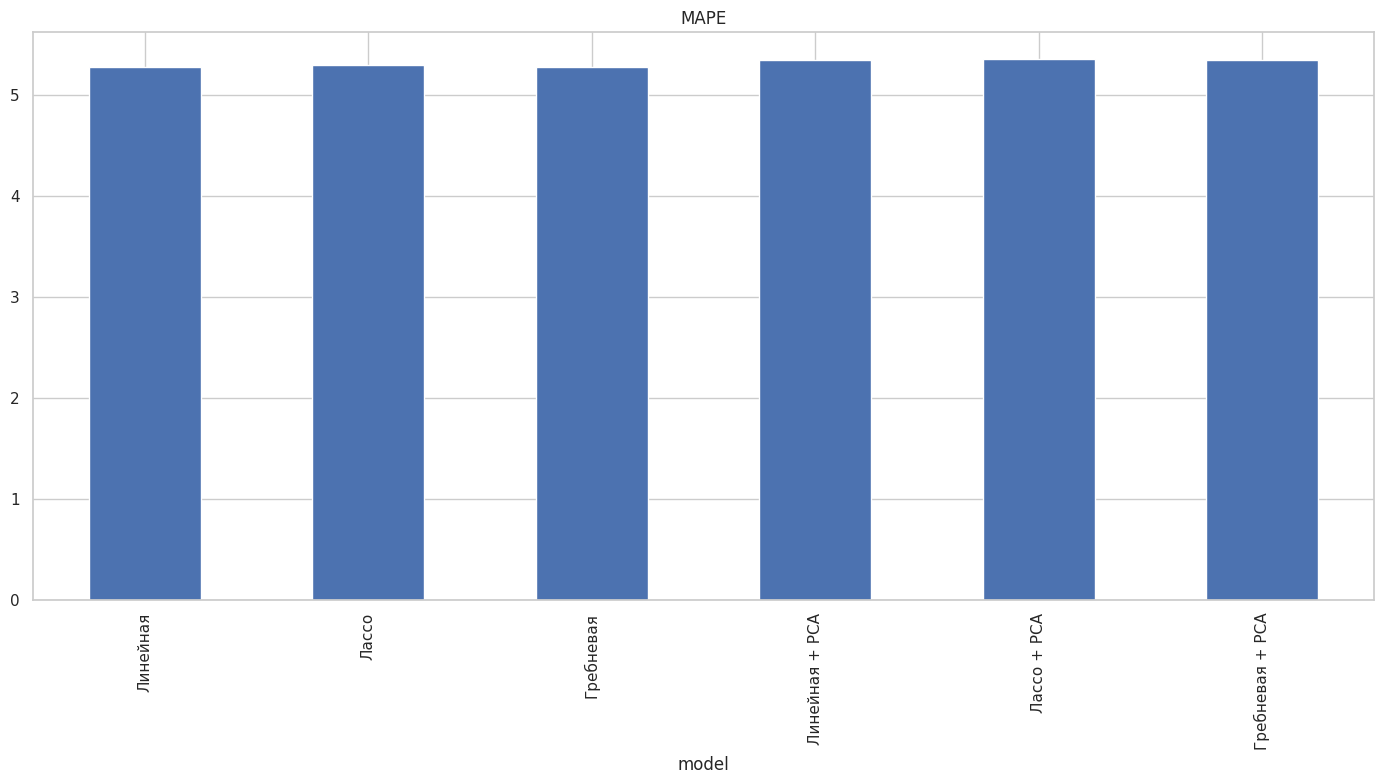

In [110]:
results_dt.set_index('model')[['MAPE']].plot(
    kind='bar', subplots=True, figsize=(14, 8), legend=False
)
plt.tight_layout()
plt.show()

MAPE незначительно вырос после PCA у всех трёх моделей. Это значит, что средняя ошибка в процентах от реального рейтинга чуть увеличилась, однако разница очень мала (с 5.30 до 5.35).

### Корреляционная матрица после PCA

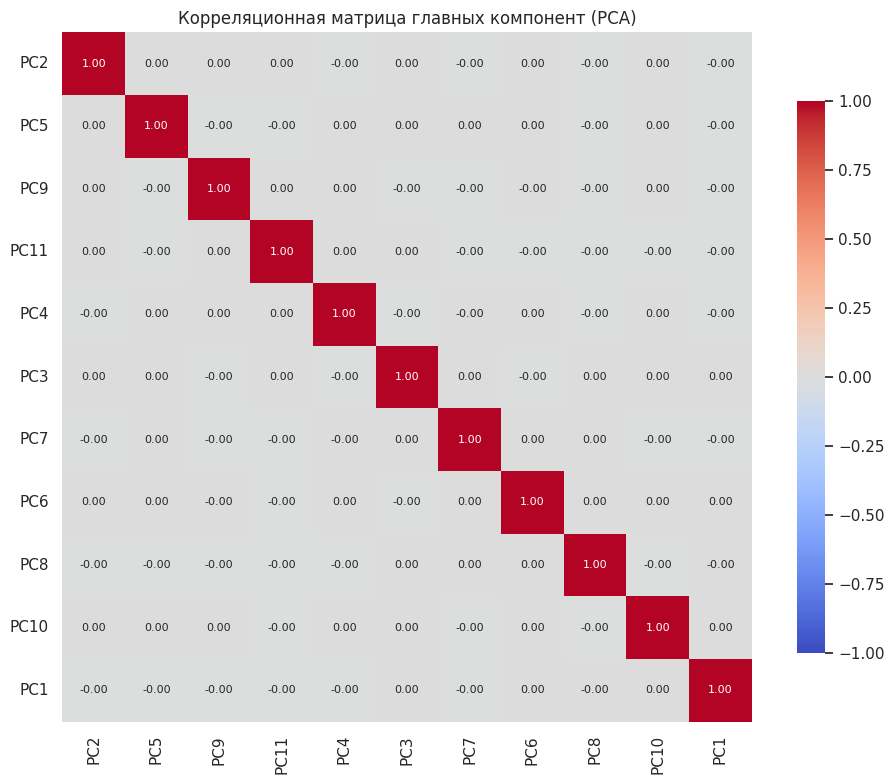

In [111]:
pca_df = pd.DataFrame(
    x_train_pca, columns=[f'PC{i+1}' for i in range(x_train_pca.shape[1])]
)

pca_df['Rating'] = y_train.values

matrix_pca = (
    pca_df.corr()['Rating'].drop('Rating').sort_values(ascending=False)
)

ordered_pc = matrix_pca.index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(pca_df[ordered_pc].corr(), annot=True, cmap='coolwarm',
            center=0, fmt='.2f', square=True,
            vmin=-1, vmax=1, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица главных компонент (PCA)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# **Заключение**
Выявлена умеренная корреляция целевой переменной Rating с признаками Price (r = +0.45) и Year (r = -0.34). Остальные признаки, включая страну-производителя (Country), слабо влияют на рейтинг (|r| ≤ 0.12). Корреляционная матрица также показала умеренную связь между Country_France и Country_Italy (r = -0.35).

Расчёт VIF подтвердил наличие умеренной мультиколлинеарности между признаками стран: Country_Italy (VIF = 9.12) и Country_France (VIF = 8.46) - значения близки к порогу 10, но не превышают его. Числовые признаки (Year, Price, NumberOfRatings) имеют VIF < 1.3 - мультиколлинеарности между ними нет.

Исходные модели линейной, Лассо и Гребневой регрессии показали умеренное значение метрики R2 (около 0.16), при этом все три модели дали практически одинаковый результат - регуляризация не дала значительного улучшения из-за умеренной мультиколлинеарности. Кросс-валидация подтвердила устойчивость моделей (CV R2 = 0.23 ± 0.03) и отсутствие переобучения.

Метод главных компонент позволил снизить размерность признакового пространства с 13 до 11 компонент, сохранив при этом 95% дисперсии. Сжатие оказалось слабым - это объясняется тем, что страны слабо коррелируют между собой, поэтому PCA не может их существенно сжать. График каменистой осыпи не имеет выраженного "локтя", что подтверждает отсутствие доминирующих направлений дисперсии в данных.

Модели, обученные на главных компонентах, показали метрики немного выше, чем исходные: R2 вырос с 0.163 до 0.198 (+21%), RMSE снизился с 0.276 до 0.270 (-2%), а MAPE незначительно вырос с 5.28% до 5.35%. Наилучшая модель - Лассо + PCA (R2 = 0.199, RMSE = 0.270). Улучшение метрик объясняется устранением мультиколлинеарности, стабилизацией коэффициентов и удалением шума вместе с 5% дисперсии. Умеренное значение R2 объясняется субъективной природой целевой переменной Rating: модель объясняет примерно 20% разброса, остальное - неучтённые факторы (сорт винограда, личные предпочтения дегустаторов, контекст дегустации, текстовые описания вин).

# **Список источников**

1.   Курс "Системы искусственного интеллекта и машинное обучение" // DiSpace НГТУ. URL: https://dispace.nstu.ru/course/965



# **Приложение. Полный листинг программного кода**

======= 2 пункт =======
Подготовка данных

Размер датасета: (13834, 8)
                                 Name  Country     Region  \
0                        Pomerol 2011   France    Pomerol   
1                          Lirac 2017   France      Lirac   
2  Erta e China Rosso di Toscana 2015    Italy    Toscana   
3                      Bardolino 2019    Italy  Bardolino   
4      Ried Scheibner Pinot Noir 2016  Austria  Carnuntum   

                  Winery  Rating  NumberOfRatings  Price    Year  
0  Château La Providence     4.2              100  95.00  2011.0  
1     Château Mont-Redon     4.3              100  15.50  2017.0  
2             Renzo Masi     3.9              100   7.45  2015.0  
3             Cavalchina     3.5              100   8.72  2019.0  
4            Markowitsch     3.9              100  29.15  2016.0  

Информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13834 entries, 0 to 13833
Data columns (total 8 columns):
 #   Column           Non-Nul

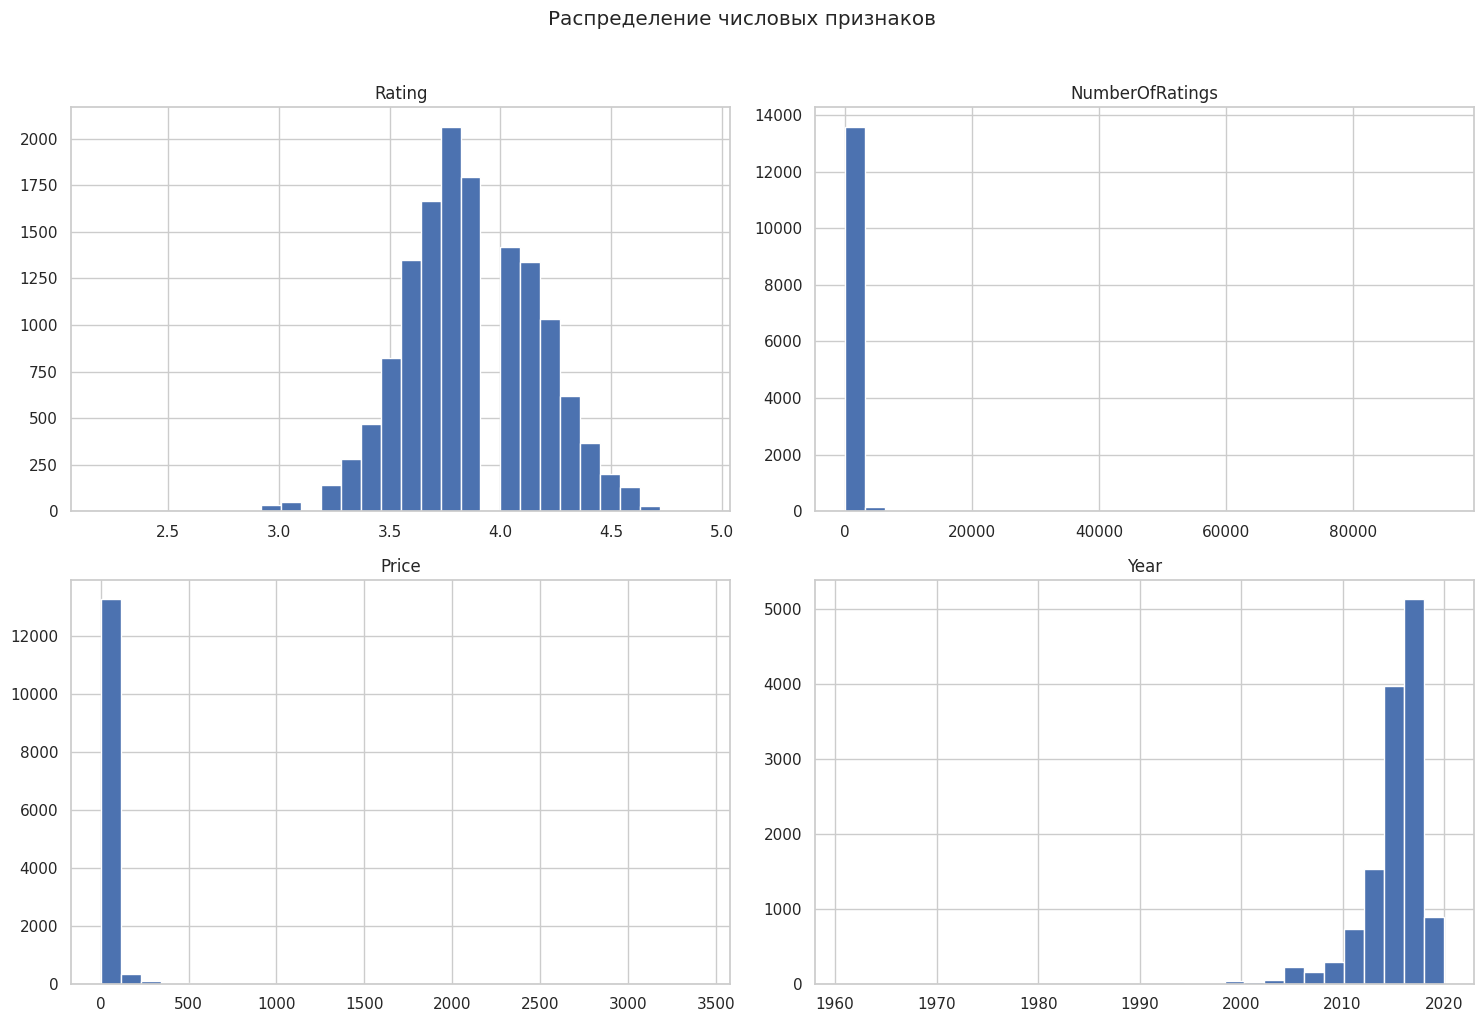

Визуализация категориальных признаков


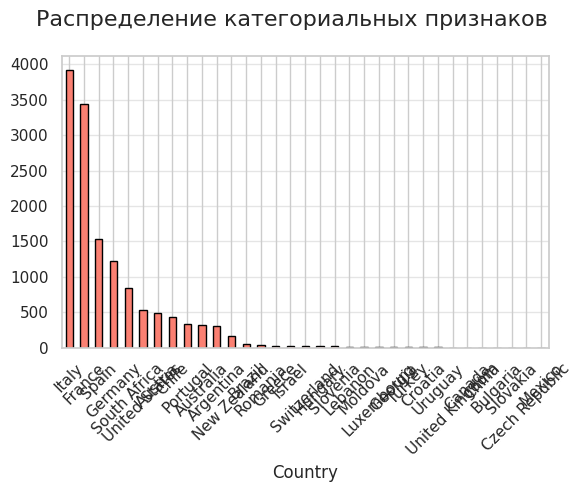

Визуализация целевой переменной


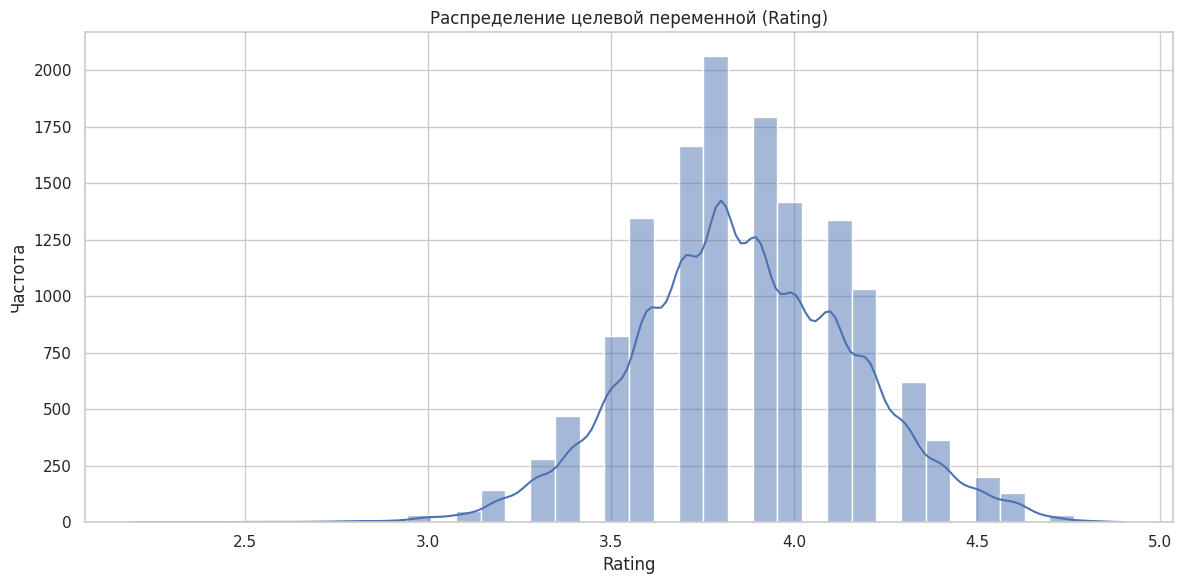


======= 3 пункт =======
Предобработка данных

После удаления лишних столбцов и пропусков осталось: (13090, 5)

Объединение редко попадающихся стран в 'Other'
Страны до объединения: 33
Страны после объединения: 11
После кодирования: (13090, 14)

======= 4 пункт =======
Вывод корреляционной матрицы


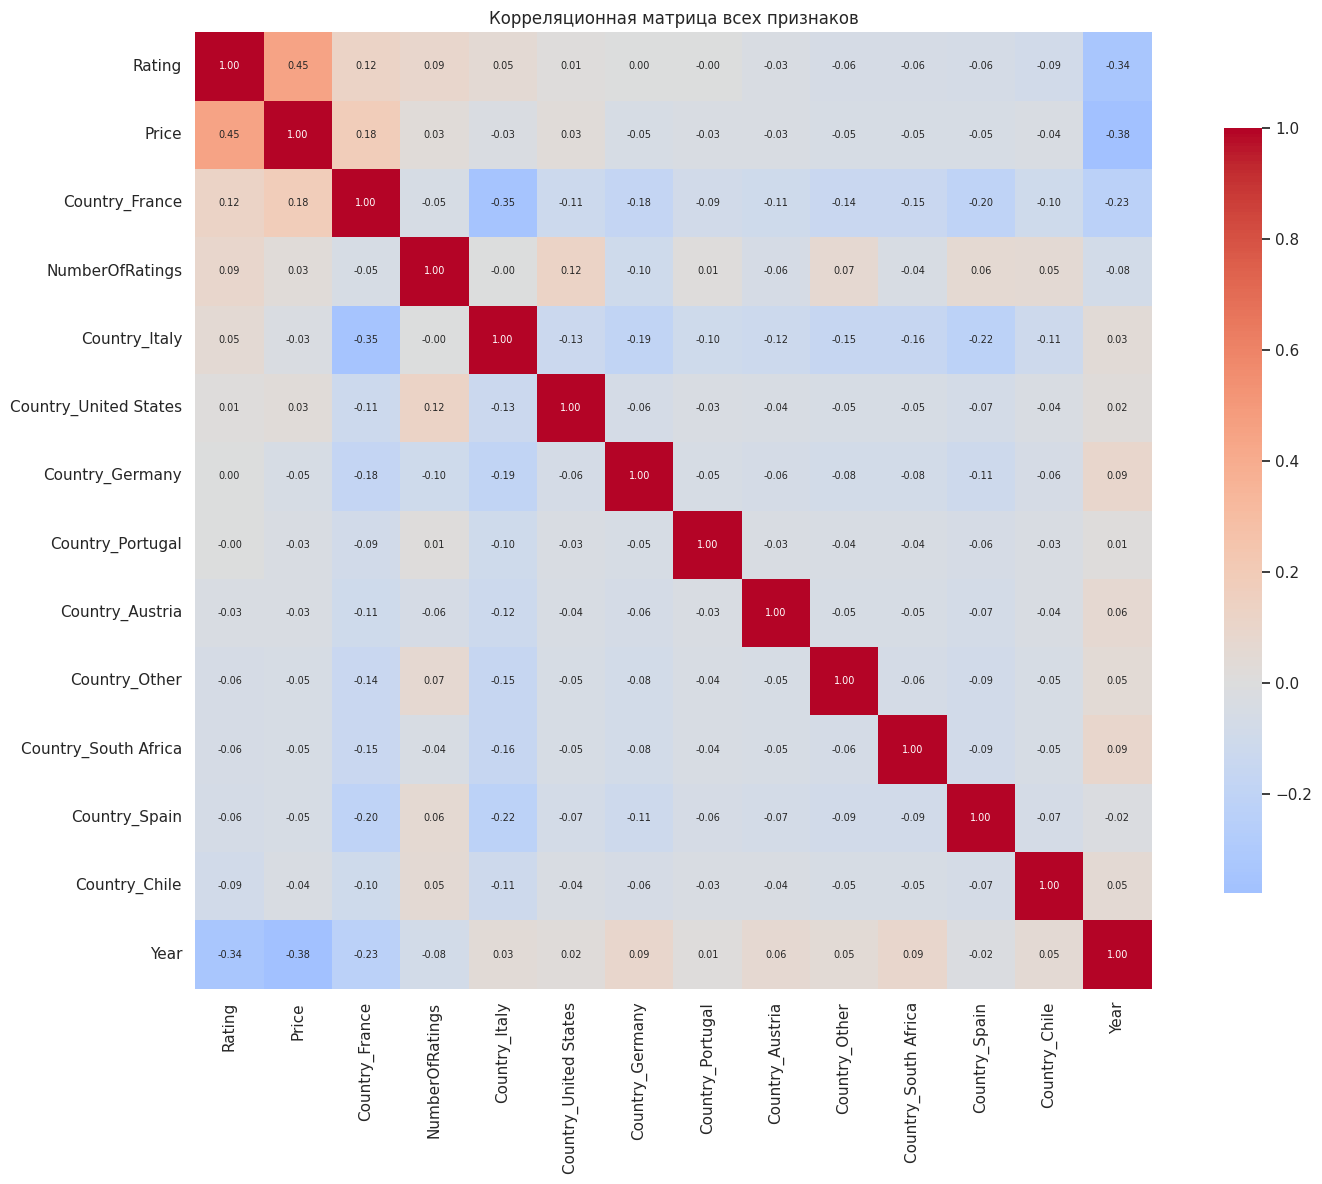


VIF:
                  feature       VIF
7           Country_Italy  9.118859
5          Country_France  8.460329
11          Country_Spain  5.103667
6         Country_Germany  4.343656
10   Country_South Africa  3.435038
8           Country_Other  3.200556
12  Country_United States  2.583460
3         Country_Austria  2.437759
4           Country_Chile  2.297098
9        Country_Portugal  1.996475
2                    Year  1.228018
1                   Price  1.187725
0         NumberOfRatings  1.049432

======= 5 пункт =======
Деление на тестовую и тренировочную выборки

Тренировочная: (10472, 13) Тестовая: (2618, 13) 

Регрессионные модели
Линейная	 | RMSE=0.2757886662268048	 | R²=0.1632145922095979	 | MAPE=5.28156730215262%
Лассо		 | RMSE=0.27674596171790367	 | R²=0.1573953453153939	 | MAPE=5.3011735616871505%
Гребневая	 | RMSE=0.27580275837568075	 | R²=0.16312907451244596	 | MAPE=5.281888610045836%

Кросс-валидация
CV R² (Линейная): 0.2302618425192172 ± 0.03327802017361817
CV R² (

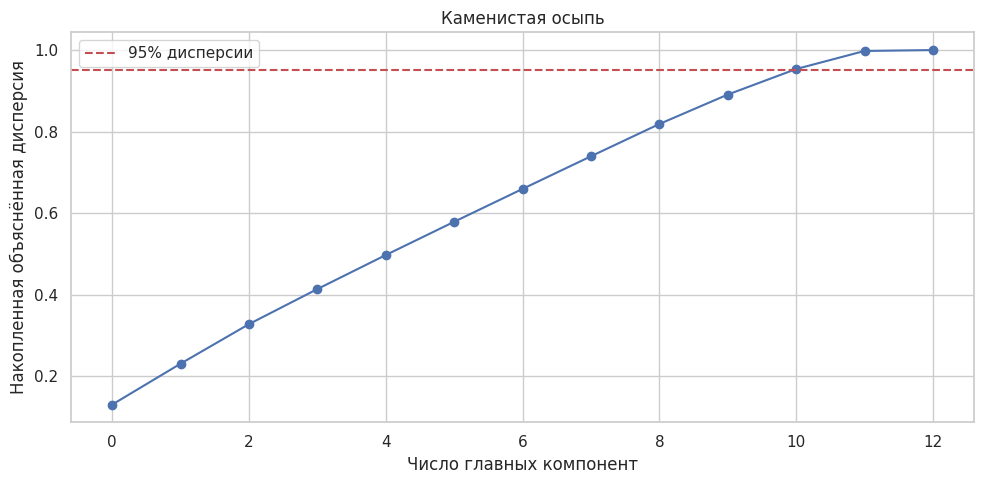

Оптимальное число компонент для 95% дисперсии: 11
Размер после PCA: (10472, 11)

======= 7 пункт =======
Регрессионные модели после PCA
Линейная	 | RMSE=0.2757886662268048	 | R²=0.1632145922095979	 | MAPE=5.28156730215262%
Лассо		 | RMSE=0.27674596171790367	 | R²=0.1573953453153939	 | MAPE=5.3011735616871505%
Гребневая	 | RMSE=0.27580275837568075	 | R²=0.16312907451244596	 | MAPE=5.281888610045836%
Линейная + PCA	 | RMSE=0.2699841220246889	 | R²=0.19806768080490134	 | MAPE=5.351161624370181%
Лассо + PCA	 | RMSE=0.26978375167768837	 | R²=0.1992575569336481	 | MAPE=5.3550860686606%
Гребневая + PCA	 | RMSE=0.26998239410219776	 | R²=0.19807794564896763	 | MAPE=5.351179437237487%


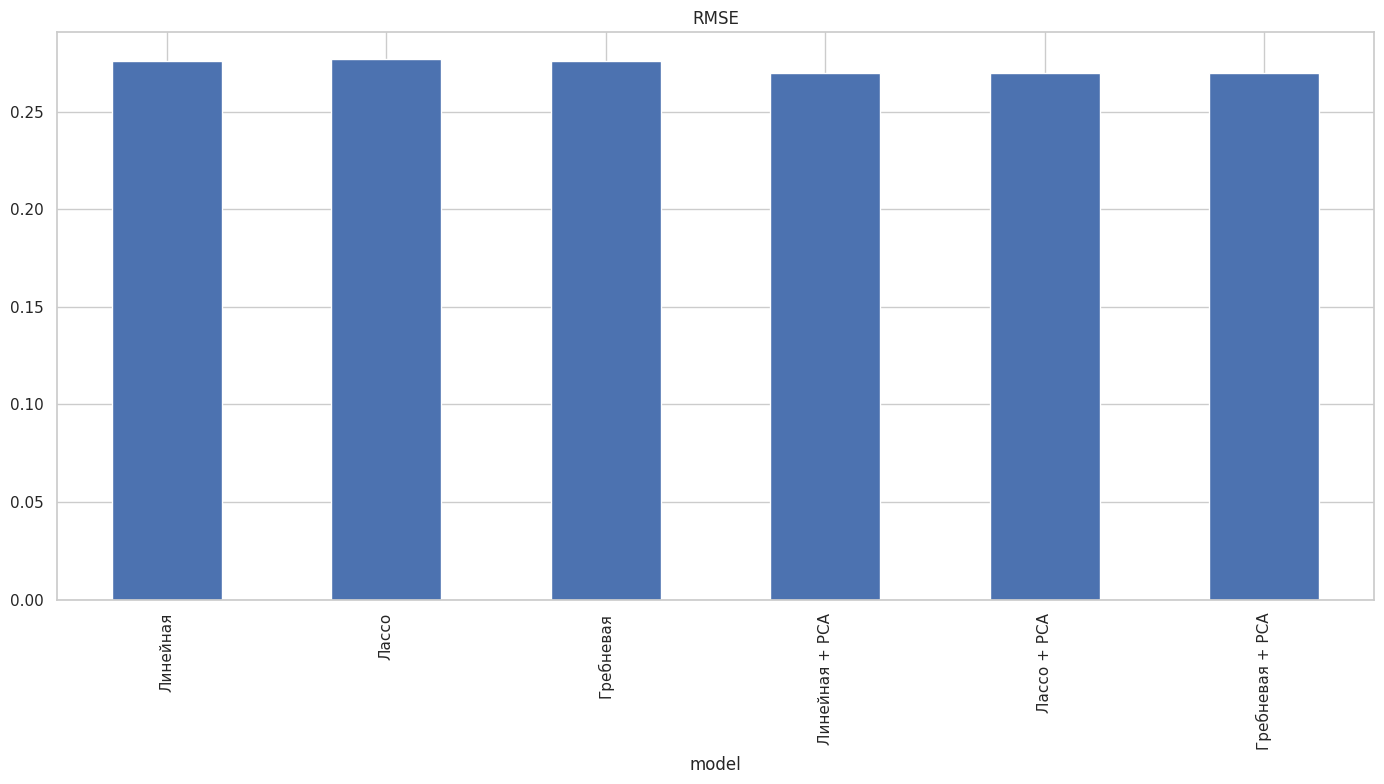

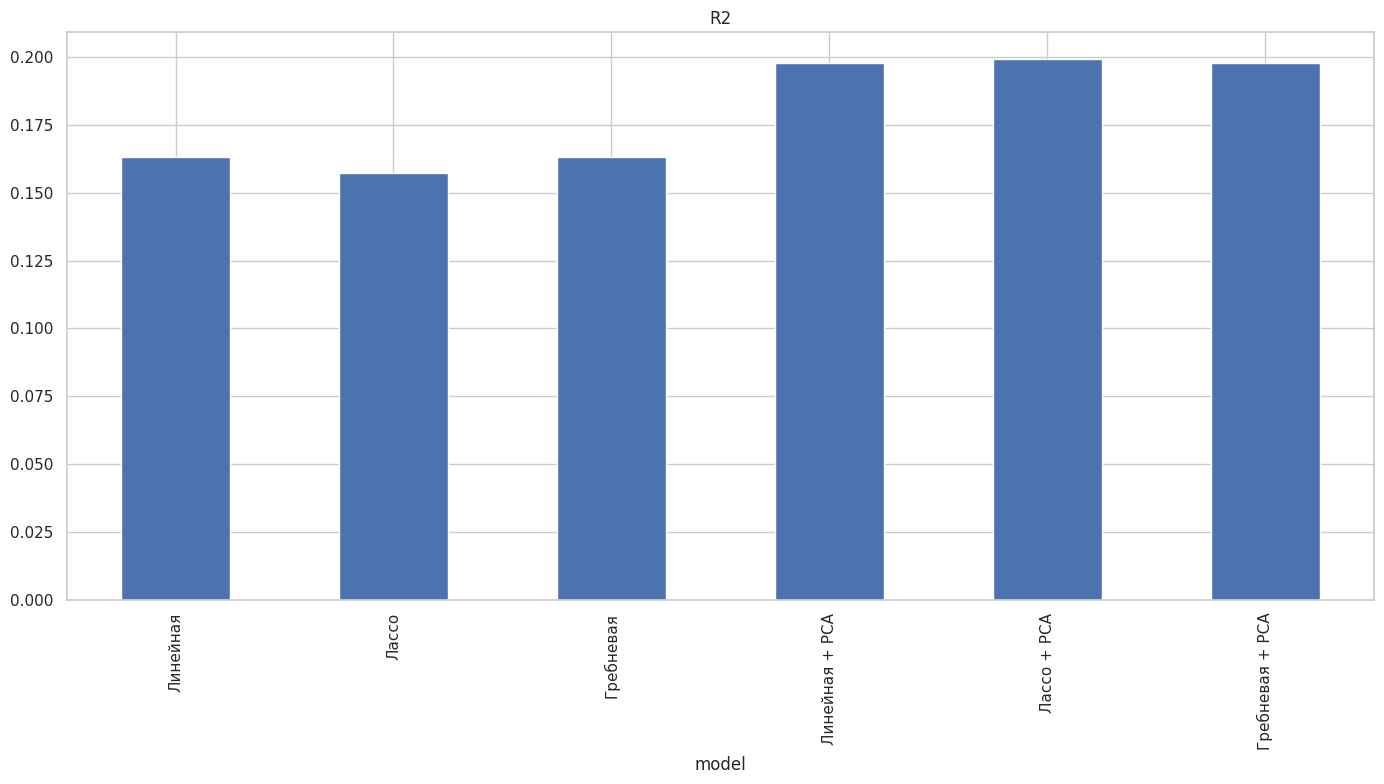

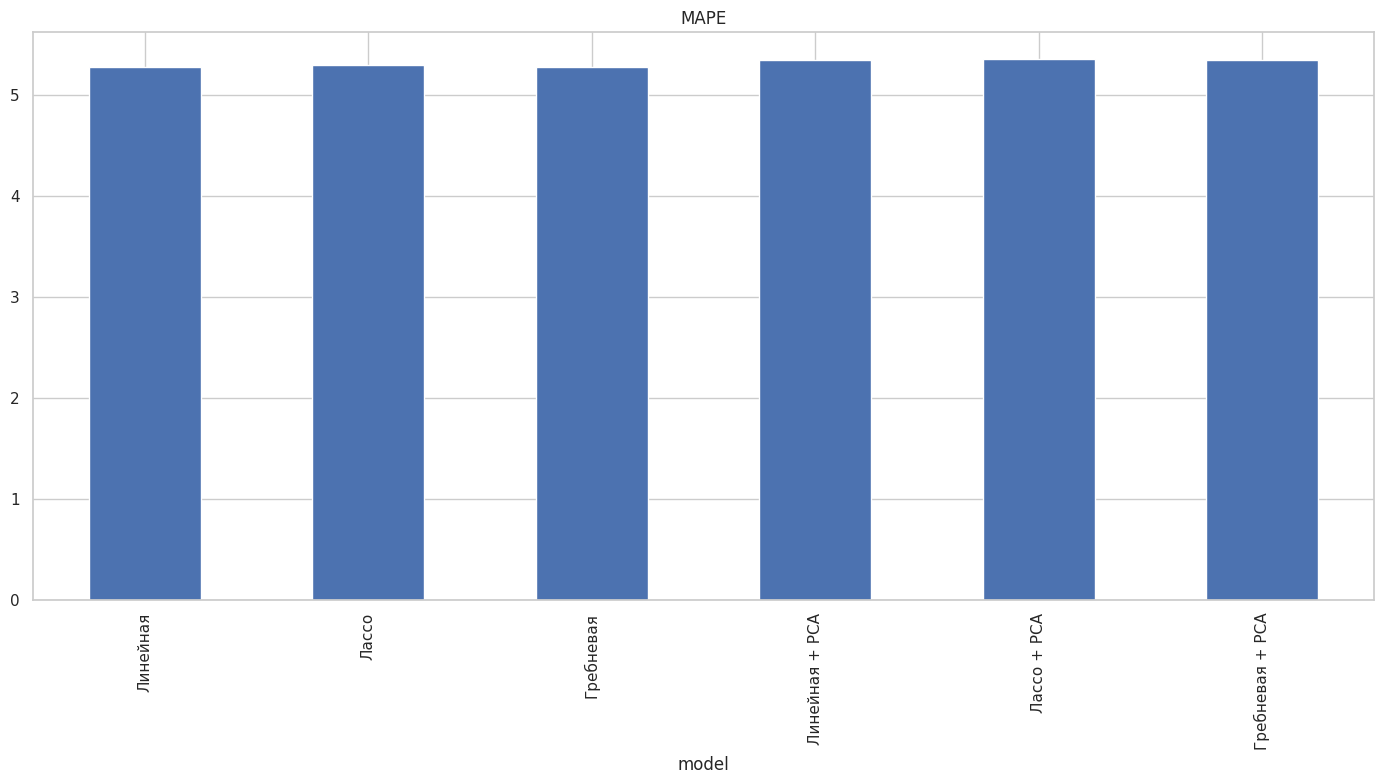

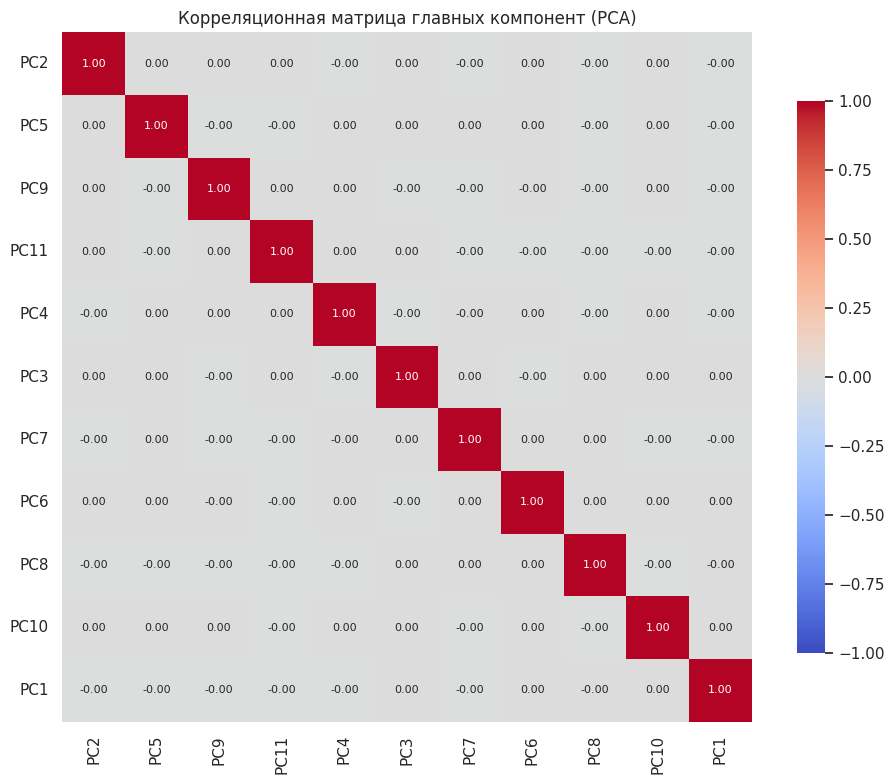

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor


def Print_Results(results):
    for res in results:
        if res['model'] == "Лассо":
            print(f"{res['model']}\t\t | RMSE={res['RMSE']}\t | R²={res['R2']}\t | MAPE={res['MAPE']}%")
        else:
            print(f"{res['model']}\t | RMSE={res['RMSE']}\t | R²={res['R2']}\t | MAPE={res['MAPE']}%")


def Evaluate(model, x_tr, y_tr, x_te, y_te, name):
    model.fit(x_tr, y_tr)
    y_pred = model.predict(x_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    mape = mean_absolute_percentage_error(y_te, y_pred) * 100
    return {'model': name, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}


sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
RANDOM_STATE = 42

red = pd.read_csv('Red.csv')
white = pd.read_csv('White.csv')
rose = pd.read_csv('Rose.csv')
sparkling = pd.read_csv('Sparkling.csv')

print("======= 2 пункт =======")
print("Подготовка данных\n")

dt = pd.concat([red, white, rose, sparkling], ignore_index=True)
dt['Year'] = pd.to_numeric(dt['Year'], errors='coerce')

print("Размер датасета:", dt.shape)
print(dt.head())

print("\nИнформация о датасете")

dt.info()
print("\nОписательная статистика числовых признаков:\n", dt.describe())
print("\nПропуски по столбцам:")
print(dt.isnull().sum().sort_values(ascending=False))

print("\nУдаление уникальных признаков")
drop_columns = ['Name', 'Winery', 'Region']
for column in drop_columns:
    if column in dt.columns:
        dt = dt.drop(columns=column)

print("\nВизуализация числовых признаков")
numeric_cols = dt.select_dtypes(include=[np.number]).columns
dt[numeric_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle('Распределение числовых признаков', y=1.02)
plt.tight_layout()
plt.show()

print("Визуализация категориальных признаков")
categorical_features = dt.select_dtypes(include=['object']).columns.tolist()

num_categorical = len(categorical_features)

if num_categorical > 0:
    fig, axes = plt.subplots(1, num_categorical, figsize=(6 * num_categorical, 5))
    if num_categorical == 1:
        axes = [axes]

    fig.suptitle('Распределение категориальных признаков', fontsize=16)

    for i, col in enumerate(categorical_features):
        top_values = dt[col].value_counts()
        top_values.plot(kind='bar', ax=axes[i],
                        color='salmon', edgecolor='black')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(axis='y', alpha=0.5)

    plt.tight_layout()
    plt.show()

print("Визуализация целевой переменной")
sns.histplot(dt['Rating'].dropna(), kde=True, bins=40)
plt.title('Распределение целевой переменной (Rating)')
plt.xlabel('Rating')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

target = 'Rating'


print("\n======= 3 пункт =======")
print("Предобработка данных\n")
dt = dt.dropna(subset=numeric_cols).copy()
print("После удаления лишних столбцов и пропусков осталось:", dt.shape)

print("\nОбъединение редко попадающихся стран в 'Other'")
category_columns = dt.select_dtypes(include=['object']).columns.tolist()

if 'Country' in dt.columns:
    print("Страны до объединения:", dt['Country'].nunique())
    countries = dt['Country'].value_counts().head(10).index
    dt['Country'] = dt['Country'].where(
        dt['Country'].isin(countries), 'Other'
    )
    print("Страны после объединения:", dt['Country'].nunique())

dt = pd.get_dummies(dt, columns=category_columns, drop_first=True)
print("После кодирования:", dt.shape)


print("\n======= 4 пункт =======")
print("Вывод корреляционной матрицы")
matrix = dt.corr()['Rating'].sort_values(ascending=False)
ordered_cols = matrix.index.tolist()

plt.figure(figsize=(16, 12))
sns.heatmap(dt[ordered_cols].corr(), annot=True, cmap='coolwarm',
            center=0, fmt='.2f', square=True,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица всех признаков')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

x = dt.drop(columns=[target])
y = dt[target]

print("\nVIF:")
x_vif = x.copy()
x_vif = x_vif.replace([np.inf, -np.inf], np.nan).fillna(x_vif.median())

vif_data = pd.DataFrame()
vif_data["feature"] = x_vif.columns
vif_data["VIF"] = [variance_inflation_factor(x_vif.values, i)
                   for i in range(x_vif.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))


print("\n======= 5 пункт =======")
print("Деление на тестовую и тренировочную выборки\n")
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Тренировочная:", x_train.shape, "Тестовая:", x_test.shape, "\n")

print("Регрессионные модели")
results = []
results.append(Evaluate(LinearRegression(),
                        x_train, y_train, x_test, y_test, "Линейная"))
results.append(Evaluate(Lasso(alpha=0.001, max_iter=10000),
                        x_train, y_train, x_test, y_test, "Лассо"))
results.append(Evaluate(Ridge(alpha=1.0),
                        x_train, y_train, x_test, y_test, "Гребневая"))

Print_Results(results)

print("\nКросс-валидация")
cv = cross_val_score(LinearRegression(), x, y, cv=5, scoring='r2')
print(f"CV R² (Линейная): {cv.mean()} ± {cv.std()}")
cv = cross_val_score(Lasso(), x, y, cv=5, scoring='r2')
print(f"CV R² (Лассо): {cv.mean()} ± {cv.std()}")
cv = cross_val_score(Ridge(), x, y, cv=5, scoring='r2')
print(f"CV R² (Гребневая): {cv.mean()} ± {cv.std()}")


print("\n======= 6 пункт =======")
print("Стандартизация данных\n")
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("PCA")
pca_full = PCA()
pca_full.fit(x_train_scaled)

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.xlabel('Число главных компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.title('Каменистая осыпь')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

variance = np.cumsum(pca_full.explained_variance_ratio_)
num_components = np.argmax(variance >= 0.95) + 1
print(f"Оптимальное число компонент для 95% дисперсии: {num_components}")

pca = PCA(n_components=num_components)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)
print("Размер после PCA:", x_train_pca.shape)


print("\n======= 7 пункт =======")
print("Регрессионные модели после PCA")
results.append(Evaluate(LinearRegression(),
                        x_train_pca, y_train, x_test_pca, y_test,
                        "Линейная + PCA"))
results.append(Evaluate(Lasso(alpha=0.001, max_iter=10000),
                        x_train_pca, y_train, x_test_pca, y_test,
                        "Лассо + PCA"))
results.append(Evaluate(Ridge(alpha=1.0),
                        x_train_pca, y_train, x_test_pca, y_test,
                        "Гребневая + PCA"))

Print_Results(results)

results_dt = pd.DataFrame(results)

results_dt.set_index('model')[['RMSE']].plot(
    kind='bar', subplots=True, figsize=(14, 8), legend=False
)
plt.tight_layout()
plt.show()

results_dt.set_index('model')[['R2']].plot(
    kind='bar', subplots=True, figsize=(14, 8), legend=False
)
plt.tight_layout()
plt.show()

results_dt.set_index('model')[['MAPE']].plot(
    kind='bar', subplots=True, figsize=(14, 8), legend=False
)
plt.tight_layout()
plt.show()


pca_df = pd.DataFrame(
    x_train_pca, columns=[f'PC{i+1}' for i in range(x_train_pca.shape[1])]
)

pca_df['Rating'] = y_train.values

matrix_pca = (
    pca_df.corr()['Rating'].drop('Rating').sort_values(ascending=False)
)

ordered_pc = matrix_pca.index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(pca_df[ordered_pc].corr(), annot=True, cmap='coolwarm',
            center=0, fmt='.2f', square=True,
            vmin=-1, vmax=1, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица главных компонент (PCA)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()